# Simple Extremal Search on MAPLE Output

This notebook loads MAPLE output from the R integration test and applies simple extremal search procedures in Python.

The goal is to compare:

1. True-label RMST effect
2. MAPLE-label RMST effect
3. Monte Carlo feasible assignment range
4. Simulated tempering extrema
5. Fast EO-style extrema

In [1]:
from pathlib import Path
from dataclasses import dataclass
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

@dataclass
class Config:
    tau: float = 12.0
    n_mc: int = 5000
    max_iter: int = 5000

config = Config()

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
HANDOFF_PATH = PROJECT_ROOT / "results" / "maple_outputs" / "maple_python_handoff.csv"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Project root:", PROJECT_ROOT)
print("Handoff path:", HANDOFF_PATH)
print(config)

Project root: /Users/jonathanma/Desktop/DS Projects/covar-recon-IPD
Handoff path: /Users/jonathanma/Desktop/DS Projects/covar-recon-IPD/results/maple_outputs/maple_python_handoff.csv
Config(tau=12.0, n_mc=5000, max_iter=5000)


In [2]:
maple_df = pd.read_csv(HANDOFF_PATH)

maple_df = maple_df.rename(
    columns={
        "Z": "treatment",
        "label": "z_true",
        "maple_label": "z_maple",
    }
)

observed_df = maple_df[["time", "event", "treatment"]].copy()
z_true = maple_df["z_true"].astype(int).values
z_maple = maple_df["z_maple"].astype(int).values

maple_df.head()

,time,event,treatment,z_true,z_maple
0,1.757999,1,0,0,1
1,18.378767,0,1,1,1
2,2.339394,1,0,1,0
3,13.610037,0,0,0,1
4,20.247962,0,1,1,1


In [3]:
print("True labels:")
display(pd.crosstab(observed_df["treatment"], z_true, margins=True))

print("MAPLE labels:")
display(pd.crosstab(observed_df["treatment"], z_maple, margins=True))

K1 = int(z_true[observed_df["treatment"].values == 1].sum())
K0 = int(z_true[observed_df["treatment"].values == 0].sum())

print("Treatment subgroup-positive:", K1)
print("Control subgroup-positive:", K0)

True labels:


col_0,0,1,All
treatment,,,
0,98,118,216
1,102,82,184
All,200,200,400


MAPLE labels:


col_0,0,1,All
treatment,,,
0,98,118,216
1,102,82,184
All,200,200,400


Treatment subgroup-positive: 82
Control subgroup-positive: 118


# RMST Construction

In [4]:
def estimate_rmst(time, event, tau):
    kmf = KaplanMeierFitter()
    kmf.fit(time, event_observed=event)

    surv = kmf.survival_function_.reset_index()
    surv.columns = ["time", "survival"]

    times = np.concatenate([[0], surv["time"].values])
    survival = np.concatenate([[1.0], surv["survival"].values])

    times = np.clip(times, 0, tau)
    keep = times <= tau
    times = times[keep]
    survival = survival[keep]

    if times[-1] < tau:
        times = np.append(times, tau)
        survival = np.append(survival, survival[-1])

    return np.sum(np.diff(times) * survival[:-1])


def rmst_treatment_effect(df, z, tau):
    df_eval = df.copy()
    df_eval["z"] = z

    treated = df_eval[(df_eval["treatment"] == 1) & (df_eval["z"] == 1)]
    control = df_eval[(df_eval["treatment"] == 0) & (df_eval["z"] == 1)]

    rmst_treated = estimate_rmst(treated["time"], treated["event"], tau)
    rmst_control = estimate_rmst(control["time"], control["event"], tau)

    return rmst_treated - rmst_control

In [5]:
true_effect = rmst_treatment_effect(observed_df, z_true, config.tau)
maple_effect = rmst_treatment_effect(observed_df, z_maple, config.tau)

print(f"True-label RMST effect: {true_effect:.3f}")
print(f"MAPLE-label RMST effect: {maple_effect:.3f}")

True-label RMST effect: 1.765
MAPLE-label RMST effect: 1.817


In [6]:
def generate_feasible_assignment(treatment, K1, K0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    z = np.zeros(len(treatment), dtype=int)

    treated_idx = np.where(treatment == 1)[0]
    control_idx = np.where(treatment == 0)[0]

    treated_positive = rng.choice(treated_idx, size=K1, replace=False)
    control_positive = rng.choice(control_idx, size=K0, replace=False)

    z[treated_positive] = 1
    z[control_positive] = 1

    return z

In [7]:
rng = np.random.default_rng(SEED)
treatment = observed_df["treatment"].values

mc_effects = []

for _ in range(config.n_mc):
    z_mc = generate_feasible_assignment(treatment, K1, K0, rng=rng)
    mc_effects.append(rmst_treatment_effect(observed_df, z_mc, config.tau))

mc_effects = np.array(mc_effects)

pd.Series(mc_effects).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])

count    5000.000000
mean        0.262260
std         0.460325
min        -1.328309
5%         -0.512191
25%        -0.051241
50%         0.265158
75%         0.576834
95%         1.019715
max         1.820454
dtype: float64

# Simulated Tempering

In [19]:
def propose_maple_swap(z, treatment, event, rng):
    """
    Swap labels within a (treatment,event) stratum.

    This preserves all MAPLE count constraints exactly.
    """

    z_new = z.copy()

    arm = rng.choice([0, 1])
    ev = rng.choice([0, 1])

    stratum = np.where(
        (treatment == arm) &
        (event == ev)
    )[0]

    pos_idx = stratum[z[stratum] == 1]
    neg_idx = stratum[z[stratum] == 0]

    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return z_new

    i = rng.choice(pos_idx)
    j = rng.choice(neg_idx)

    z_new[i], z_new[j] = z_new[j], z_new[i]

    return z_new

In [20]:
def simulated_tempering_search(
    df,
    initial_z,
    tau,
    temperatures,
    n_iter=5000,
    mode="max",
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    treatment = df["treatment"].values

    z_current = initial_z.copy()
    effect_current = rmst_treatment_effect(df, z_current, tau)
    score_current = effect_current if mode == "max" else -effect_current

    best_z = z_current.copy()
    best_effect = effect_current
    best_score = score_current

    temp_idx = len(temperatures) // 2
    T = temperatures[temp_idx]

    trace = []

    for it in range(n_iter):
        z_prop = propose_maple_swap(z_current,treatment,event,rng)
        effect_prop = rmst_treatment_effect(df, z_prop, tau)
        score_prop = effect_prop if mode == "max" else -effect_prop

        delta = score_prop - score_current

        accept = delta >= 0 or rng.uniform() < np.exp(delta / T)

        if accept:
            z_current = z_prop
            effect_current = effect_prop
            score_current = score_prop

        if score_current > best_score:
            best_z = z_current.copy()
            best_effect = effect_current
            best_score = score_current

        if rng.uniform() < 0.10:
            new_temp_idx = temp_idx + rng.choice([-1, 1])
            if 0 <= new_temp_idx < len(temperatures):
                temp_idx = new_temp_idx
                T = temperatures[temp_idx]

        trace.append(
            {
                "iteration": it,
                "effect": effect_current,
                "best_effect": best_effect,
                "temperature": T,
            }
        )

    return {
        "best_z": best_z,
        "best_effect": best_effect,
        "trace": pd.DataFrame(trace),
    }

In [22]:
temperatures = np.array([0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00])
z_init = z_maple.copy()
event = observed_df["event"].values

st_max = simulated_tempering_search(
    observed_df,
    z_init,
    config.tau,
    temperatures,
    n_iter=config.max_iter,
    mode="max",
    seed=SEED,
)

st_min = simulated_tempering_search(
    observed_df,
    z_init,
    config.tau,
    temperatures,
    n_iter=config.max_iter,
    mode="min",
    seed=SEED + 1,
)

print(f"ST minimum: {st_min['best_effect']:.3f}")
print(f"ST maximum: {st_max['best_effect']:.3f}")

ST minimum: -0.757
ST maximum: 2.972


# Extremal Optimization

In [23]:
def rank_based_patient_selection(scores, gamma, rng):
    order = np.argsort(scores)
    ranks = np.arange(1, len(scores) + 1)

    probs = ranks ** (-gamma)
    probs = probs / probs.sum()

    selected_rank = rng.choice(len(scores), p=probs)
    return order[selected_rank]


def select_maple_swap_partner(z, treatment, event, i, rng):
    """
    Select a swap partner from the same (treatment, event) stratum.

    This preserves MAPLE's full count/event constraints.
    """
    arm = treatment[i]
    ev = event[i]
    opposite_label = 1 - z[i]

    candidates = np.where(
        (treatment == arm) &
        (event == ev) &
        (z == opposite_label)
    )[0]

    if len(candidates) == 0:
        return None

    return rng.choice(candidates)


def eo_patient_scores_fast(df, z, mode="max"):
    time = df["time"].values
    treatment = df["treatment"].values

    time_std = (time - time.mean()) / time.std()

    if mode == "max":
        desirability = np.where(treatment == 1, time_std, -time_std)
    elif mode == "min":
        desirability = np.where(treatment == 1, -time_std, time_std)
    else:
        raise ValueError("mode must be 'max' or 'min'")

    return np.where(z == 1, desirability, -desirability)

In [27]:
def extremal_optimization_search_fast(
    df,
    initial_z,
    tau,
    n_iter=5000,
    gamma=1.5,
    mode="max",
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    treatment = df["treatment"].values
    event = df["event"].values

    z_current = initial_z.copy()
    effect_current = rmst_treatment_effect(df, z_current, tau)

    best_z = z_current.copy()
    best_effect = effect_current

    trace = []

    for it in range(n_iter):
        local_scores = eo_patient_scores_fast(df, z_current, mode=mode)

        i = rank_based_patient_selection(local_scores, gamma=gamma, rng=rng)
        j = select_maple_swap_partner(z_current, treatment, event, i, rng)

        if j is None:
            continue

        z_prop = z_current.copy()
        z_prop[i], z_prop[j] = z_prop[j], z_prop[i]

        effect_prop = rmst_treatment_effect(df, z_prop, tau)

        z_current = z_prop
        effect_current = effect_prop

        improved = effect_current > best_effect if mode == "max" else effect_current < best_effect

        if improved:
            best_z = z_current.copy()
            best_effect = effect_current

        trace.append(
            {
                "iteration": it,
                "effect": effect_current,
                "best_effect": best_effect,
            }
        )

    return {
        "best_z": best_z,
        "best_effect": best_effect,
        "trace": pd.DataFrame(trace),
    }

In [28]:
eo_max = extremal_optimization_search_fast(
    observed_df,
    z_init,
    config.tau,
    n_iter=config.max_iter,
    mode="max",
    seed=SEED,
)

eo_min = extremal_optimization_search_fast(
    observed_df,
    z_init,
    config.tau,
    n_iter=config.max_iter,
    mode="min",
    seed=SEED + 2,
)

print(f"EO minimum: {eo_min['best_effect']:.3f}")
print(f"EO maximum: {eo_max['best_effect']:.3f}")

EO minimum: -3.377
EO maximum: 5.838


# Comparison

In [29]:
def check_feasible(z, treatment, K1, K0):
    return {
        "binary_ok": set(np.unique(z)).issubset({0, 1}),
        "treated_ok": int(z[treatment == 1].sum()) == K1,
        "control_ok": int(z[treatment == 0].sum()) == K0,
        "treated_positive": int(z[treatment == 1].sum()),
        "control_positive": int(z[treatment == 0].sum()),
    }


feasibility = pd.DataFrame([
    {"method": "MAPLE", **check_feasible(z_maple, treatment, K1, K0)},
    {"method": "ST min", **check_feasible(st_min["best_z"], treatment, K1, K0)},
    {"method": "ST max", **check_feasible(st_max["best_z"], treatment, K1, K0)},
    {"method": "EO min", **check_feasible(eo_min["best_z"], treatment, K1, K0)},
    {"method": "EO max", **check_feasible(eo_max["best_z"], treatment, K1, K0)},
])

feasibility

,method,binary_ok,treated_ok,control_ok,treated_positive,control_positive
0,MAPLE,True,True,True,82,118
1,ST min,True,True,True,82,118
2,ST max,True,True,True,82,118
3,EO min,True,True,True,82,118
4,EO max,True,True,True,82,118


In [30]:
comparison = pd.DataFrame({
    "Method": [
        "True labels",
        "MAPLE labels",
        "Monte Carlo",
        "Simulated Tempering",
        "Fast EO",
    ],
    "Minimum": [
        true_effect,
        maple_effect,
        mc_effects.min(),
        st_min["best_effect"],
        eo_min["best_effect"],
    ],
    "Maximum": [
        true_effect,
        maple_effect,
        mc_effects.max(),
        st_max["best_effect"],
        eo_max["best_effect"],
    ],
})

comparison["Width"] = comparison["Maximum"] - comparison["Minimum"]
comparison

,Method,Minimum,Maximum,Width
0,True labels,1.764923,1.764923,0.000000
1,MAPLE labels,1.817029,1.817029,0.000000
2,Monte Carlo,-1.328309,1.820454,3.148763
3,Simulated Tempering,-0.757334,2.971968,3.729303
4,Fast EO,-3.377183,5.838325,9.215507


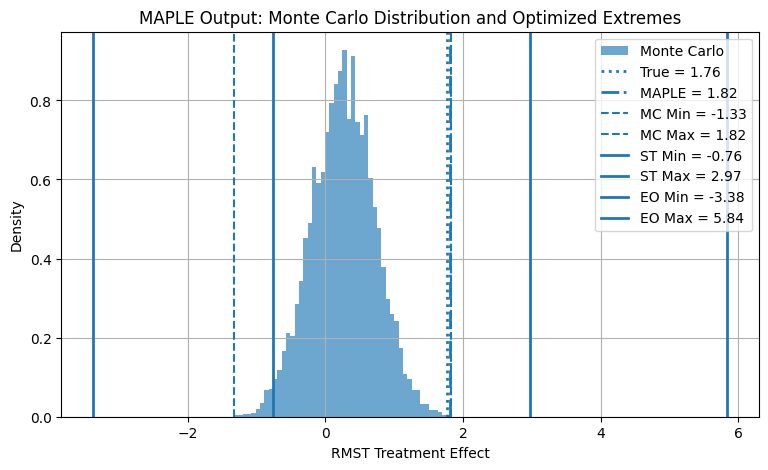

In [31]:
plt.figure(figsize=(9, 5))

plt.hist(mc_effects, bins=50, density=True, alpha=0.65, label="Monte Carlo")

plt.axvline(true_effect, linestyle=":", linewidth=2, label=f"True = {true_effect:.2f}")
plt.axvline(maple_effect, linestyle="-.", linewidth=2, label=f"MAPLE = {maple_effect:.2f}")

plt.axvline(mc_effects.min(), linestyle="--", label=f"MC Min = {mc_effects.min():.2f}")
plt.axvline(mc_effects.max(), linestyle="--", label=f"MC Max = {mc_effects.max():.2f}")

plt.axvline(st_min["best_effect"], linewidth=2, label=f"ST Min = {st_min['best_effect']:.2f}")
plt.axvline(st_max["best_effect"], linewidth=2, label=f"ST Max = {st_max['best_effect']:.2f}")

plt.axvline(eo_min["best_effect"], linewidth=2, label=f"EO Min = {eo_min['best_effect']:.2f}")
plt.axvline(eo_max["best_effect"], linewidth=2, label=f"EO Max = {eo_max['best_effect']:.2f}")

plt.xlabel("RMST Treatment Effect")
plt.ylabel("Density")
plt.title("MAPLE Output: Monte Carlo Distribution and Optimized Extremes")
plt.legend()
plt.show()

The EO extrema are much wider than MC and ST. Because this fast EO implementation uses a surrogate patient-level fitness score, these values should be interpreted as heuristic boundary candidates. They are mathematically feasible under the count constraints, but they may not satisfy the richer MAPLE summary-statistic constraints unless those checks are added explicitly.

In [32]:
def compute_full_maple_constraints(df, z, treatment_col="treatment", event_col="event"):
    """
    MAPLE-style constraints:
    n_g_z  = number assigned subgroup g with treatment z
    n_g_z_ev = number assigned subgroup g with treatment z and event = 1
    """
    out = {}

    treatment = df[treatment_col].values
    event = df[event_col].values

    for g in [0, 1]:
        for a in [0, 1]:
            mask = (z == g) & (treatment == a)
            out[f"n_{g}_z{a}"] = int(mask.sum())
            out[f"n_{g}_z{a}_ev"] = int((mask & (event == 1)).sum())

    return out


target_constraints = compute_full_maple_constraints(
    observed_df,
    z_true
)

assignments_to_check = {
    "True": z_true,
    "MAPLE": z_maple,
    "ST min": st_min["best_z"],
    "ST max": st_max["best_z"],
    "EO min": eo_min["best_z"],
    "EO max": eo_max["best_z"],
}

rows = []

for name, z in assignments_to_check.items():
    current = compute_full_maple_constraints(
        observed_df,
        z
    )

    for key, target_value in target_constraints.items():
        current_value = current[key]

        rows.append({
            "assignment": name,
            "constraint": key,
            "target": target_value,
            "current": current_value,
            "match": target_value == current_value,
            "difference": current_value - target_value,
        })

full_constraint_check = pd.DataFrame(rows)

constraint_summary = (
    full_constraint_check
    .groupby("assignment")["match"]
    .agg(["sum", "count", "mean"])
    .reset_index()
    .rename(columns={"sum": "constraints_satisfied", "count": "total_constraints", "mean": "constraint_rate"})
)

constraint_summary

,assignment,constraints_satisfied,total_constraints,constraint_rate
0,EO max,8,8,1.0
1,EO min,8,8,1.0
2,MAPLE,8,8,1.0
3,ST max,8,8,1.0
4,ST min,8,8,1.0
5,True,8,8,1.0


In [33]:
full_constraint_check[
    full_constraint_check["match"] == False
].sort_values(["assignment", "constraint"])

,assignment,constraint,target,current,match,difference


In [35]:
st_effects = np.concatenate([
    st_max["trace"]["effect"].values,
    st_min["trace"]["effect"].values
])

eo_effects = np.concatenate([
    eo_max["trace"]["effect"].values,
    eo_min["trace"]["effect"].values
])

print("ST samples:", len(st_effects))
print("EO samples:", len(eo_effects))

ST samples: 10000
EO samples: 10000


In [36]:
comparison_dist = pd.DataFrame({
    "Method": ["MC", "ST", "EO"],
    "Mean": [
        np.mean(mc_effects),
        np.mean(st_effects),
        np.mean(eo_effects),
    ],
    "Q05": [
        np.quantile(mc_effects, 0.05),
        np.quantile(st_effects, 0.05),
        np.quantile(eo_effects, 0.05),
    ],
    "Median": [
        np.median(mc_effects),
        np.median(st_effects),
        np.median(eo_effects),
    ],
    "Q95": [
        np.quantile(mc_effects, 0.95),
        np.quantile(st_effects, 0.95),
        np.quantile(eo_effects, 0.95),
    ],
})

comparison_dist

,Method,Mean,Q05,Median,Q95
0,MC,0.262260,-0.512191,0.265158,1.019715
1,ST,0.968189,-0.159608,0.950997,2.265056
2,EO,1.276367,-3.119915,1.866466,5.609054


MC estimates:

What does the feasible distribution look like?

ST/EO estimate:

How far can we push the treatment effect while remaining feasible?

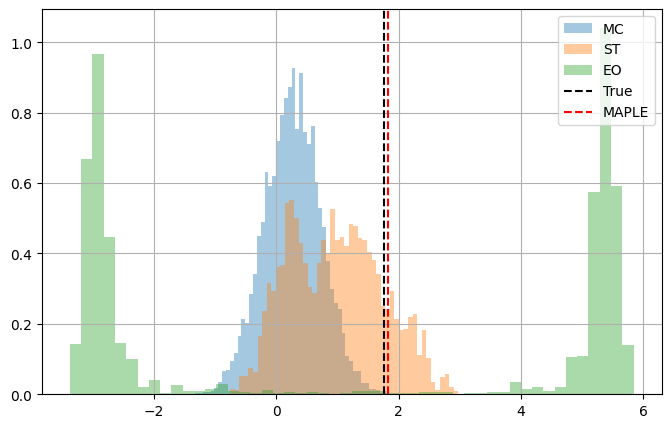

In [37]:
plt.hist(mc_effects, bins=50, density=True, alpha=0.4, label="MC")
plt.hist(st_effects, bins=50, density=True, alpha=0.4, label="ST")
plt.hist(eo_effects, bins=50, density=True, alpha=0.4, label="EO")

plt.axvline(true_effect, color="black", linestyle="--", label="True")
plt.axvline(maple_effect, color="red", linestyle="--", label="MAPLE")

plt.legend()
plt.show()

In [39]:
mc_percentile_true =np.mean(mc_effects <= true_effect)

mc_percentile_maple =np.mean(mc_effects <= maple_effect)

print("MC percentile (True):", mc_percentile_true)
print("MC percentile (MAPLE):", mc_percentile_maple)

MC percentile (True): 0.9998
MC percentile (MAPLE): 0.9998
